In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import seaborn as sns
from collections import Counter
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib
from matplotlib import rc
rc("text", usetex=False)
import warnings
warnings.filterwarnings('ignore')

sns.set(font_scale=2) 
sns.set_style("white")
# sns.set_style("ticks")
%matplotlib inline

# Helper function

In [2]:
def paired_line(data, lines, column1, cond1_ls, x_axis):
    plt.rcParams["figure.figsize"] = (3,10)
    ax = sns.pointplot(x=cond1_ls, y=column1, data=data)
    sns.despine()
    

def non_unique(l):
    def low(x):
        return x.lower() if isinstance(x, str) else x
    c = Counter(map(low, l))
    return [x for x in l if c[low(x)] > 1]

# AgRP chemogenetics

In [3]:
data = pd.read_csv('chemogenetics.csv', encoding='cp1252')
data = data[(data['receptor'].isin(['Gq', 'mCher', 'hGlyR', 'YFP'])) & (data.histology_validation != 'invalid') & (data.histology_validation != 'invalid_test')]
data_pre = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_post = data.groupby(['receptor', 'state_after']).size().reset_index(name='n')
data_pre['CNO_cond'] = 'CNO-'
data_post['CNO_cond'] = 'CNO+'

data_pre = data_pre.rename(columns = {'state_D2': 'state'})
data_post = data_post.rename(columns = {'state_after': 'state'})

data_t = pd.concat([data_pre, data_post], ignore_index=True)
data_t.reset_index(inplace = True)

def adding_zero_row(df):

    combinations = df.groupby(['CNO_cond', 'receptor'])['state'].apply(set).reset_index()
    missing_rows = []
    for index, row in combinations.iterrows():
        if 'Agg+' not in row['state']:
            missing_rows.append({'CNO_cond': row['CNO_cond'], 'receptor': row['receptor'], 'state': 'Agg+', 'n': 0})
        if 'Agg-' not in row['state']:
            missing_rows.append({'CNO_cond': row['CNO_cond'], 'receptor': row['receptor'], 'state': 'Agg-', 'n': 0})

    # Convert the list of dictionaries to a DataFrame
    missing_df = pd.DataFrame(missing_rows)

    # Concatenate the new rows with the original DataFrame
    updated_df = pd.concat([df, missing_df], ignore_index=True)

    updated_df.sort_values(by=['CNO_cond', 'receptor', 'state'], inplace=True)
    updated_df.reset_index(drop=True, inplace=True)

    return updated_df

data_t = adding_zero_row(data_t)

data_count = data_t.groupby(['CNO_cond', 'receptor']).n.sum().reset_index(name = 'count')
data_per = data_t.merge(data_count, how = 'outer', on = ['CNO_cond', 'receptor'])
data_per['percentage'] = data_per['n'] / data_per['count'] *100

## food intake

In [4]:
Gq_dat = data[data['receptor'].isin(['Gq'])]
stat, p = stats.ttest_rel(Gq_dat['food_consumption_null'],
                           Gq_dat['food_consumption_CNO'])
print(p)

9.698631809291145e-05


In [5]:
def arange_drifted_bar(df, cat):
  columns = ['mice_ID', 'receptor', 'food_consumption_null', 'food_consumption_CNO']
  filtered_df = df[columns].reset_index(drop = True).reset_index()
  stacked_df = filtered_df[columns[-2:]].stack().reset_index()
  stacked_df.columns = ['index', 'condition', 'food_consumption']
  merged_df = pd.merge(filtered_df, stacked_df, on = 'index')
  merged_df.receptor = pd.Categorical(merged_df.receptor, categories=cat)
  merged_df.condition = pd.Categorical(merged_df.condition, categories=['food_consumption_null', 'food_consumption_CNO'])
  merged_df.sort_values(['receptor', 'condition'], inplace=True)
  merged_df2 = merged_df.copy()



  def encode_session(x):
    if x=='mCher' or x=='YFP':
      return 1
    else:
      return 0
    

  def offset_session(row):
    if row['condition']=='food_consumption_null':
      return row['receptor']-0.2
    else:
      return row['receptor']+0.2
    
  merged_df2['receptor'] = merged_df2['receptor'].apply(encode_session)
  merged_df2['receptor'] = merged_df2.apply(offset_session, axis=1)
 

  return merged_df, merged_df2


def plot_bar(df, df2):
  plt.subplots(figsize = [2,3])
  sns.swarmplot(x = 'receptor', y = 'food_consumption', hue = 'condition', data = df, dodge = True, palette=['darkgray', 'Tab:orange'])
  sns.barplot(x = 'receptor', y = 'food_consumption',  hue = 'condition', data = df, palette=['darkgray', 'Tab:orange'],alpha = 0.7)
  sns.lineplot(x = 'receptor', y = 'food_consumption', hue='mice_ID', data=df2,
                  estimator=None,  palette= ['black'], legend=False, alpha = 0.5)
  sns.despine()

  ax = plt.gca()
  ax.set_xticks(np.arange(2), (df.receptor.unique()))
  ax.get_legend().remove()
  plt.ylabel('1h food \nconsumption(g)')
  plt.xlabel('')
  plt.savefig(f'output_figures/{df.receptor.unique()[0]}mchemo_food.pdf', dpi=300,bbox_inches='tight')

def plot_unlinked(df, palette):
  plt.subplots(figsize = [1.7,2])
  sns.swarmplot(x = 'receptor', y = 'food_consumption_CNO', data = df[df.condition == 'food_consumption_CNO'], dodge = False, palette=palette)
  sns.barplot(x = 'receptor', y = 'food_consumption_CNO', data = df[df.condition == 'food_consumption_CNO'], palette=palette,alpha = 0.7)
  sns.despine()
  plt.ylabel('1h food \nintake(g)')
  plt.xticks(rotation=45)
  plt.xlabel('')

def ttest_ind(df, receptors):
  _, p = stats.ttest_ind(df[(df.condition == 'food_consumption_CNO') & (df.receptor == receptors[0])].food_consumption, 
                            df[(df.condition == 'food_consumption_CNO') & (df.receptor == receptors[1])].food_consumption)
  return p


Gq: 7.611466963651264e-06, hGlyR: 0.008754006813114008


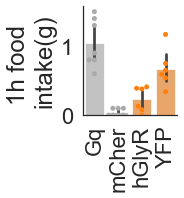

In [6]:
df_gq = data[data.receptor.isin(['Gq', 'mCher'])]
df_hgly = data[data.receptor.isin(['hGlyR', 'YFP'])]

df_gq, df_gq2 = arange_drifted_bar(df_gq, ['Gq', 'mCher'])
df_hgly, df_hgly2 = arange_drifted_bar(df_hgly, ['hGlyR', 'YFP'])
# plot_bar(df_gq, df_gq2)
# plot_bar(df_hgly, df_hgly2)

# plot_unlinked(df_gq, ['darkgray', 'darkgray'])
p_gq = ttest_ind(df_gq, ['Gq', 'mCher'])

# plot_unlinked(df_hgly, ['Tab:orange', 'Tab:orange'])
p_hgly = ttest_ind(df_hgly, ['hGlyR', 'YFP'])

print(f'Gq: {p_gq}, hGlyR: {p_hgly}')

agg_data = pd.concat([df_gq, df_hgly])
plot_unlinked(agg_data, ['darkgray','darkgray', 'Tab:orange', 'Tab:orange'])
plt.xticks(rotation=90)
plt.savefig('output_figures/chemo_food.pdf', dpi=300,bbox_inches='tight')

In [7]:
df_gq.head()

,index,mice_ID,receptor,food_consumption_null,food_consumption_CNO,condition,food_consumption
14,7,JKAJ10.4d,Gq,0.1,0.8,food_consumption_null,0.1
16,8,JKAJ10.4e,Gq,0.0,0.9,food_consumption_null,0.0
18,9,JKAJ10.4f,Gq,0.0,0.8,food_consumption_null,0.0
20,10,JKAJ8.5e,Gq,0.0,0.6,food_consumption_null,0.0
22,11,JKAJ8.6c,Gq,0.1,1.5,food_consumption_null,0.1


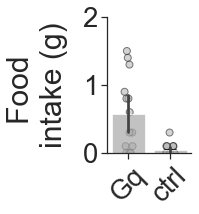

In [8]:
# CHEMOGENETIC ACTIVATION
sns.set(font_scale=2.5) 
sns.set_style("ticks")
plt.subplots(figsize = [1.5,2.5])
# sns.swarmplot(x = 'receptor', y = 'food_consumption', data = df_gq, dodge = False, 
#               palette=['darkgrey', 'darkgrey'], order=['Gq', 'mCher'])
sns.stripplot(x='receptor', y='food_consumption', data = df_gq, jitter=True, dodge=False, order=['Gq', 'mCher'],
                   marker='o', size=7, linewidth=1, edgecolor='black', alpha=0.5, zorder=0, palette=['darkgrey', 'darkgrey'])
sns.barplot(x = 'receptor', y = 'food_consumption', data = df_gq, 
            palette=['darkgrey', 'darkgrey'],alpha = 0.7, order=['Gq', 'mCher'])

ax = plt.gca()
ax.set_xticklabels(('Gq', 'ctrl'), rotation=45)
# ax.get_legend().remove()
plt.ylim(top=2)
plt.ylabel('Food \nintake (g)', labelpad=15)
plt.xlabel('')
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/mchemo_food.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [9]:
# ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
#                  linewidth=1.7, showfliers = False, palette = triple)

NameError: name 'ephys' is not defined

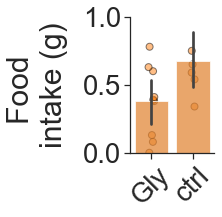

In [10]:
# CHEMOGENETIC INHIBITION
sns.set(font_scale=2.5) 
sns.set_style("ticks")
plt.subplots(figsize = [1.5,2.5])
# sns.swarmplot(x = 'receptor', y = 'food_consumption', data = df_hgly, dodge = False, 
#               palette=['darkgrey', 'darkgrey'], order=['hGlyR', 'YFP'])

sns.stripplot(x='receptor', y='food_consumption', data = df_hgly, jitter=True, dodge=False, order=['hGlyR', 'YFP'],
                   marker='o', size=7, linewidth=1, edgecolor='black', alpha=0.5, zorder=0, palette=['Tab:orange', 'Tab:orange'])
sns.barplot(x = 'receptor', y = 'food_consumption', data = df_hgly, 
            palette=['Tab:orange', 'Tab:orange'],alpha = 0.7, order=['hGlyR', 'YFP'])


ax = plt.gca()
ax.set_xticklabels(('Gly', 'ctrl'), rotation=45)
# ax.get_legend().remove()
plt.ylim(top=1)
plt.ylabel('Food \nintake (g)', labelpad=15)
plt.xlabel('')
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/hgly_food.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## parental behaviour

In [11]:
_, p  =  stats.fisher_exact([[14, 0], [39, 14]])
print(p)

0.030736867002218768


Gq: 0.004662004662004666, hGlyR: 0.029137529137529154


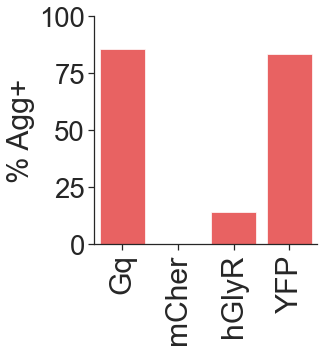

In [12]:
per_gq = data_per[data_per['receptor'].isin(['Gq', 'mCher'])]
per_hgly = data_per[data_per['receptor'].isin(['hGlyR', 'YFP'])]
# sns.set(rc={'figure.figsize':(8,5)}, font_scale = 1.3)
# sns.set_style("white", {'font.family':'serif'})


def plot_percentage(df, receptor, cat):
    df.receptor = pd.Categorical(df.receptor, categories=cat)
    # g = sns.catplot(x = 'CNO_cond',
    #                 y = 'percentage',
    #                 col = 'receptor',
    #                 data = df[df['state'] == 'Agg+'],
    #                 kind = 'bar',
    #                 alpha = 0.7, 
    #                 palette = ['red'],
    #                 aspect = 2.5/4)

    g = sns.catplot(x = 'receptor',
                    y = 'percentage',
                    data = df[(df['state'] == 'Agg+') & (df['CNO_cond'] == 'CNO+')],
                    kind = 'bar',
                    alpha = 0.7, 
                    palette = ['red'],
                    aspect = 2/2)

    g.set(xlabel = None)
    g.set_xticklabels(rotation = 90, fontsize = 30)
    g.set_ylabels(fontsize = 30)
    g.set(ylabel = '% Agg+')
    a1 = g.axes[0][0]
    # a2 = g.axes[0][1]
    # a1.set_title(receptor, pad = 20)
    # a2.set_title('Ctrl', pad = 20)

    plt.ylim([0,100])
    sns.despine()
    plt.savefig(f'output_figures/{receptor}chemogenetics.pdf', dpi=300,bbox_inches='tight')

def fisher(df, receptors):
    df = df[df.CNO_cond == 'CNO+']
    # per_gq[(per_gq['state'] == 'Agg+') & (per_gq.receptor == 'Gq')].n

    # Extract counts for each condition
    count_agg_pos_receptor0 = df[(df['state'] == 'Agg+') & (df.receptor == receptors[0])]['n'].values[0]
    count_agg_pos_receptor1 = df[(df['state'] == 'Agg+') & (df.receptor == receptors[1])]['n'].values[0]
    count_agg_neg_receptor0 = df[(df['state'] == 'Agg-') & (df.receptor == receptors[0])]['n'].values[0]
    count_agg_neg_receptor1 = df[(df['state'] == 'Agg-') & (df.receptor == receptors[1])]['n'].values[0]

    # Create the contingency table as a list of lists
    contingency_table = [[count_agg_pos_receptor0, count_agg_pos_receptor1],
                        [count_agg_neg_receptor0, count_agg_neg_receptor1]]

    # Perform Fisher's Exact Test
    _, p = stats.fisher_exact(contingency_table)


    return p

# plot_percentage(per_gq, 'Gq', ['Gq', 'mCher'])
p_gq = fisher(per_gq, ['Gq', 'mCher'])

# plot_percentage(per_hgly, 'hGlyR', ['hGlyR', 'YFP'])
p_hgly = fisher(per_hgly, ['hGlyR', 'YFP'])

print(f'Gq: {p_gq}, hGlyR: {p_hgly}')

agg_data = pd.concat([per_gq, per_hgly])
plot_percentage(agg_data, 'Gq_hGlyR', ['Gq', 'mCher', 'hGlyR', 'YFP'])



In [13]:
per_hgly

,index,receptor,state,n,CNO_cond,count,percentage
2,6.0,YFP,Agg+,5,CNO+,6,83.333333
3,7.0,YFP,Agg-,1,CNO+,6,16.666667
4,8.0,hGlyR,Agg+,1,CNO+,7,14.285714
5,9.0,hGlyR,Agg-,6,CNO+,7,85.714286
10,1.0,hGlyR,Agg+,2,CNO-,3,66.666667
11,2.0,hGlyR,Agg-,1,CNO-,3,33.333333


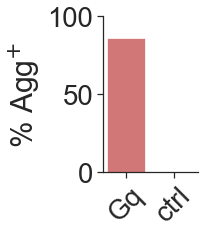

In [14]:
# CHEMOGENETIC ACTIVATION
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.catplot(x = 'receptor',
                y = 'percentage',
                data=per_gq.query("state == 'Agg+' and CNO_cond == 'CNO+'"),
                kind = 'bar',
                alpha = 0.7, 
                palette = ['Tab:red'],
                aspect = 0.85,
                height=4)

ax.set_xticklabels(('Gq', 'ctrl'), rotation=45)
plt.ylabel(r'% Agg$^{+}$', labelpad=5)
plt.xlabel('')
plt.ylim(0, 100)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/Gq_chemo.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

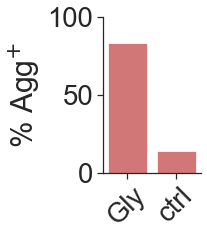

In [15]:
# CHEMOGENETIC INHIBITION
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.catplot(x = 'receptor',
                y = 'percentage',
                data=per_hgly.query("state == 'Agg+' and CNO_cond == 'CNO+'"),
                kind = 'bar',
                alpha = 0.7, 
                palette = ['Tab:red'],
                aspect = 0.85,
                height=4)

ax.set_xticklabels(('Gly', 'ctrl'), rotation=45)
plt.ylabel(r'% Agg$^{+}$', labelpad=5)
plt.xlabel('')
plt.ylim(0, 100)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/hgly_chemo.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# optogenetics

## food intake

In [16]:
df = pd.read_csv('optogenetics.csv')
val = pd.read_csv('optogenetic_validation.csv')
df = pd.merge(df, val, on = ['mice_ID', 'implantation_area'])
conditions = df.pup_light_cond.dropna().unique()

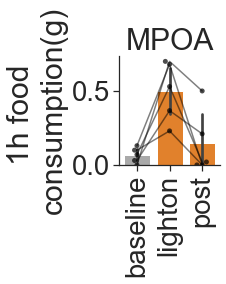

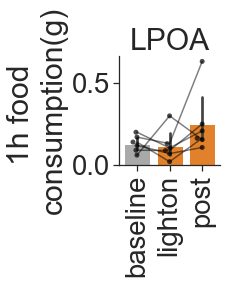

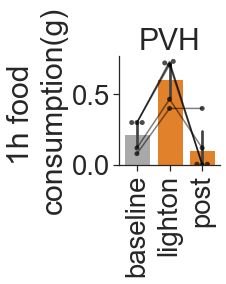

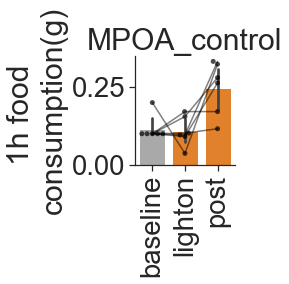

In [17]:
for area in df.implantation_area.unique():
    food_df = df[(df.pup_light_cond.isin(conditions[-3:])) & (df.histology_validation !='invalid')&(df.implantation_area == area)]
    food_df["status"] = pd.to_numeric(food_df.status)
    food_df["parental_status"] = pd.to_numeric(food_df.parental_status)

    food_df.pup_light_cond = pd.Categorical(food_df.pup_light_cond, 
                            categories=conditions[-3:],
                            ordered=True)
    

    # compute stats for food intake
    # stat, p = stats.ttest_rel(food_df[food_df.pup_light_cond == '60_lighton_food'].status,
    #                         food_df[food_df.pup_light_cond == '60_post_food'].status)
    # print(p, area)


    plt.subplots(figsize = [1.8,2])
    sns.swarmplot(x = 'pup_light_cond', y = 'status', data = food_df, palette=['black'], alpha = 0.7)
    sns.barplot(x = 'pup_light_cond', y = 'status', data = food_df, palette=['darkgray', 'Tab:orange', 'Tab:orange'])
    sns.lineplot(x="pup_light_cond", y="status", hue='mice_ID', data=food_df,
                estimator=None,  palette=['black'], legend=False, alpha = 0.5)
    
    locs, labels = plt.xticks()
    plt.xticks(locs,(['baseline','lighton', 'post']), rotation = 90)
    plt.ylabel('1h food \nconsumption(g)')
    plt.xlabel('')
    plt.title(area)
    sns.despine()
    plt.savefig(f'output_figures/{area}_food.pdf',dpi = 300,bbox_inches='tight')

In [18]:
## food intake latency and aggressive behaviour latency correlation
corr = pd.merge(df[df.pup_light_cond == '60_lighton_food'], df[(df.pup_light_cond== '30_lighton') &(df.implantation_area == 'MPOA')], on = ['mice_ID', 'implantation_area'])
corr["status_x"] = pd.to_numeric(corr.status_x)
corr["parental_status_y"] = pd.to_numeric(corr.parental_status_y)
corr["parental_status_x"] = pd.to_numeric(corr.parental_status_x)
corr = corr[corr.histology_validation_x != 'invalid']

Text(68.15000000000003, 0.5, 'Attack latency(s)')

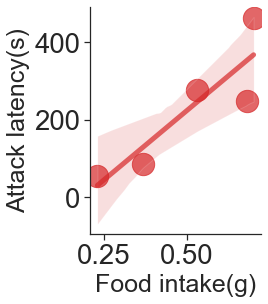

In [19]:
sns.lmplot(x = 'status_x',
            y = 'state_latency_y',
            data = corr, aspect = 1.8/2,
            scatter_kws={'s':500, 'color':'Tab:red', 'alpha': 0.7}, 
            line_kws = {'lw':5, 'color':'Tab:red', 'alpha': 0.7})
sns.despine()
plt.xlabel('Food intake(g)', fontsize = 25)
plt.ylabel('Attack latency(s)',fontsize = 25)
# plt.savefig('output_figures/attack_food_corr.pdf', dpi=300,bbox_inches='tight')

In [20]:
#test stats relationship
model = smf.ols('state_latency_y ~ status_x', data=corr).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        state_latency_y   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     10.86
Date:                Wed, 08 May 2024   Prob (F-statistic):             0.0459
Time:                        10:32:00   Log-Likelihood:                -28.211
No. Observations:                   5   AIC:                             60.42
Df Residuals:                       3   BIC:                             59.64
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -135.0202    116.036     -1.164      0.329    -504.299     234.259
status_x     717.4315    217.670      3.296      0.046      24.709    1410.154
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.434
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.304
Skew:                          -0.240   Prob(JB):                        0.859
Kurtosis:                       1.892   Cond. No.                         6.95
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## parental behaviour

In [21]:
par_df = df[(df.pup_light_cond.isin(conditions[:6]))& (df.histology_validation != 'invalid')]
count = par_df.groupby(['implantation_area', 'pup_light_cond', 'status']).size().unstack(fill_value=0).stack().reset_index(name = 'count')
ns = par_df.groupby(['implantation_area','pup_light_cond']).size().reset_index(name='n')
props = pd.merge(count, ns, on = ['implantation_area','pup_light_cond'])
props['props'] = props['count'] / props['n']
props.pup_light_cond = pd.Categorical(props.pup_light_cond, 
                      categories=conditions[:6],
                      ordered=True)
props.implantation_area = pd.Categorical(props.implantation_area, 
                      categories=['MPOA', 'LPOA', 'PVH', 'MPOA_control'],
                      ordered=True)

In [22]:
table_df = par_df[(par_df.implantation_area == 'MPOA') & (par_df.pup_light_cond.isin(['30_lighton', '30_lightoff']))]
table = pd.crosstab(table_df.pup_light_cond, table_df.status)
chi, p, dof, expected = stats.chi2_contingency(table)
print(table, p)

status          Agg+  Agg-
pup_light_cond            
30_lightoff        0     5
30_lighton         5     0 0.01141203638600166


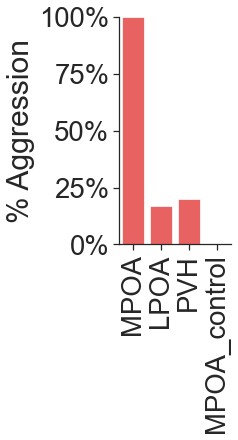

In [23]:
plot_cond = ['30_lighton']

plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)


g = sns.catplot(x = 'implantation_area',
                y = 'props',
                data = plot_df,
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 1.8/2)

g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%)')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1))
plt.ylim([0,1])
plt.xticks(rotation = 90)
plt.ylabel('% Aggression',fontsize = 30)
sns.despine()
plt.savefig('output_figures/opto_area_parental.pdf', dpi=300,bbox_inches='tight')

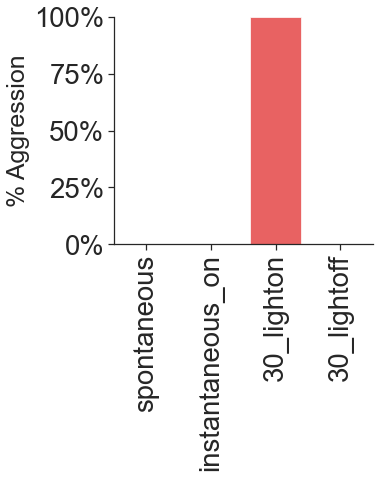

In [24]:
plot_cond = ['spontaneous', 'instantaneous_on', '30_lighton', '30_lightoff']

plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)


g = sns.catplot(x = 'pup_light_cond',
                y = 'props',
                data = plot_df[plot_df.implantation_area == 'MPOA'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 2.4/2)

g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%)')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1))
plt.ylim([0,1])
plt.xticks(rotation = 90)
plt.ylabel('% Aggression',fontsize = 25)
sns.despine()
plt.savefig('output_figures/opto_parental.pdf', dpi=300,bbox_inches='tight')

In [25]:
plot_cond = ['30_lighton']
plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)
plot_df2 = plot_df.loc[(plot_df['implantation_area'] == 'LPOA') | (plot_df['implantation_area'] == 'PVH')]
plot_df2['prob'] = plot_df2.props * 100
plot_df2

,implantation_area,pup_light_cond,status,count,n,props,prob
2,LPOA,30_lighton,Agg+,1,6,0.166667,16.666667
22,PVH,30_lighton,Agg+,1,5,0.200000,20.000000


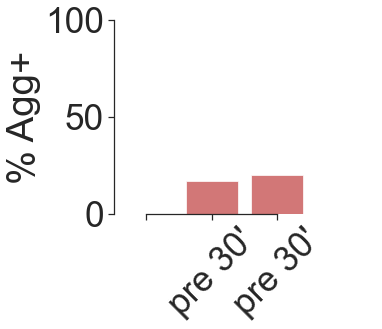

In [26]:
sns.set(rc={"figure.figsize": (2, 2)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")

g = sns.catplot(x = 'implantation_area',
                y = 'prob',
                data = plot_df2,
                kind = 'bar',
                alpha = 0.7, 
                palette = ['Tab:red'],
                aspect = 1.4)

g.set(xlabel = None)
plt.ylim([0,100])
plt.ylabel('% Agg+')
plt.xticks(range(3))
g.set_xticklabels(('','pre 30\'', 'pre 30\''), rotation=45)  # Adjust the tick labels
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/opto_area_parental.pdf',
dpi=600,bbox_inches='tight', transparent=True)

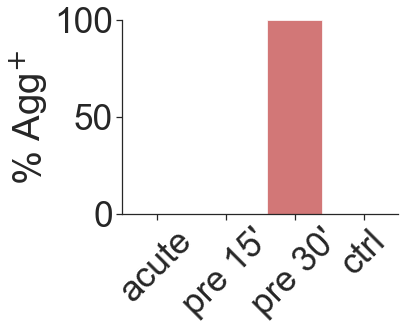

In [27]:
sns.set(rc={"figure.figsize": (2, 6)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")

plot_cond = ['spontaneous', 'instantaneous_on', '30_lighton', '30_lightoff']

plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)

plot_df['prob'] = plot_df.props * 100

g = sns.catplot(x = 'pup_light_cond',
                y = 'prob',
                data = plot_df[plot_df.implantation_area == 'MPOA'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['Tab:red'],aspect = 1.4)

g.set(xlabel = None)
plt.ylim([0,100])
plt.xticks(rotation = 90)
plt.ylabel(r'% Agg$^{+}$') 
g.set_xticklabels( ('acute', 'pre 15\'','pre 30\'', 'ctrl'), rotation=45)
sns.despine(trim=False)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_1/linked_figure1/opto_parental.pdf',
            dpi=600,bbox_inches='tight', transparent=True)

# npykd analysis

In [28]:
df = pd.read_csv('npykd.csv')
df['aggression_binary'] = df.behaviour_post.apply(lambda x: 1 if x == 'Agg+' else 0)
df.loc[df.behaviour_post == 'Agg-', 'aggression_latency'] = 15*60
# check that estrous stag is not NaN

df = df[df.behaviour_post.notnull()]

valid_df = df[df.validation != 'invalid']


kd_df = valid_df[valid_df.group == 'npykd']
ctrl_df = valid_df[valid_df.group == 'ctrl']

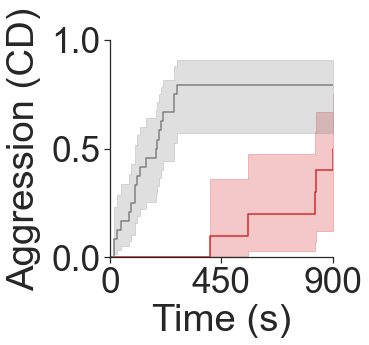

In [49]:
from lifelines import AalenJohansenFitter

# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")
sns.set_palette(['Tab:red', 'gray'])

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(kd_df.aggression_latency,kd_df.aggression_binary , event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency,ctrl_df.aggression_binary , event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove legend
plt.legend([],[], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0,1])
plt.xlim([0,900])
plt.xticks([0, 450, 900])
plt.xlabel('Time (s)')
plt.ylabel('Aggression (CD)', labelpad=10)
# plt.savefig('output_figures/npykd.pdf', dpi=300,bbox_inches='tight')
# plt.savefig('output_figures/npykd.png', dpi=300,bbox_inches='tight')
  
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/npykd.pdf',dpi=600,bbox_inches='tight', transparent=True)

In [30]:
from lifelines.statistics import logrank_test
results = logrank_test(kd_df.aggression_latency, ctrl_df.aggression_latency, event_observed_A=kd_df.aggression_binary, event_observed_B=ctrl_df.aggression_binary)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           6.40 0.01      6.45

In [31]:
from scipy.stats import mannwhitneyu
mannwhitneyu(kd_df.aggression_latency, ctrl_df.aggression_latency)

MannwhitneyuResult(statistic=221.5, pvalue=0.0013736888753850926)

In [32]:
from glob import glob
detection_path = 'npykd_detections/'
detections = glob(detection_path + '*.csv')
names = [os.path.basename(detection).split('_')[0] for detection in detections]

In [33]:
kd_cells = pd.DataFrame()
for detection, name in zip(detections, names):
    cell_num_df = pd.read_csv(detection)
    num_detection = cell_num_df[cell_num_df.Parent.isin(['Arcuate hypothalamic nucleus' ,'Median eminence'])].shape[0]

    kd_cells = pd.concat([kd_cells, pd.DataFrame({'mice_ID': name, 'num_detection': num_detection}, index = [0])])
   

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     aggression_latency   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     7.251
Date:                Wed, 08 May 2024   Prob (F-statistic):             0.0209
Time:                        10:32:32   Log-Likelihood:                -90.772
No. Observations:                  13   AIC:                             185.5
Df Residuals:                      11   BIC:                             186.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       197.7276    136.084      1.453      0.174    -101.791     497.246
num_detection     2.6203      0.973      2.693      0.021       0.479       4.762
==============================================================================
Omnibus:                        0.114   Durbin-Watson:                   1.770
Prob(Omnibus):                  0.944   Jarque-Bera (JB):                0.329
Skew:                          -0.095   Prob(JB):                        0.848
Kurtosis:                       2.244   Cond. No.                         242.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

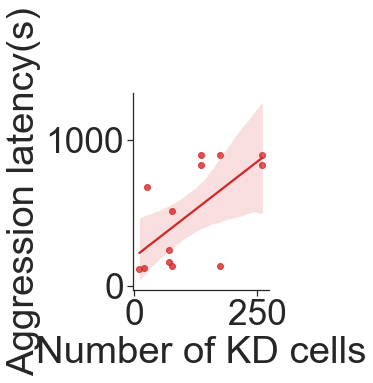

In [34]:
kd_cell_behav = pd.merge(kd_cells, df, on = 'mice_ID')
# kd_cell_behav = kd_cell_behav[kd_cell_behav.mice_ID.isin(['JKAJ33.2f', 'JKAJ30.1f', 'JKBR2.1e',  'JKBR2.1f', 'JKAJ30.2c', 'JKAJ30.2b'])]
mean_latency_cell = kd_cell_behav.groupby('num_detection').aggression_latency.mean().reset_index()


sns.lmplot(x = 'num_detection', y = 'aggression_latency', data = kd_cell_behav, aspect = 2/2)
plt.xlabel('Number of KD cells')
plt.ylabel('Aggression latency(s)')
plt.savefig('output_figures/npykd_cells_agg_correlation.pdf', dpi=300,bbox_inches='tight')
plt.savefig('output_figures/npykd_cells_agg_correlation.png', dpi=300,bbox_inches='tight')

# test significance of the relationship
model = smf.ols('aggression_latency ~ num_detection', data=kd_cell_behav).fit()
model.summary()


-2.220446049250313e-16


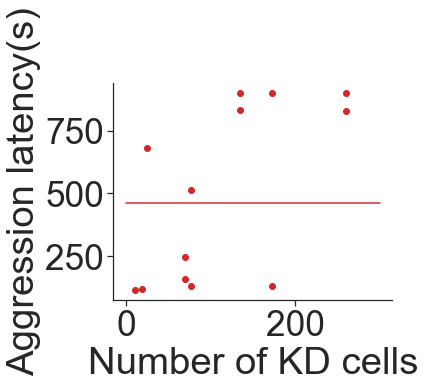

In [35]:
# curve fit to number of cells and aggression latency
from scipy.optimize import curve_fit
def logistic(x,A,x0,k,off):
    return A / (1 + np.exp(-k*(x-x0)))+off

popt, pcov = curve_fit(logistic, mean_latency_cell.num_detection, mean_latency_cell.aggression_latency)

# get r squared
residuals = mean_latency_cell.aggression_latency - logistic(mean_latency_cell.num_detection, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((mean_latency_cell.aggression_latency - np.mean(mean_latency_cell.aggression_latency))**2)
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)


x = np.linspace(0, 300, 100)
y = logistic(x, *popt)
plt.plot(x, y)
plt.scatter(kd_cell_behav.num_detection, kd_cell_behav.aggression_latency)
plt.xlabel('Number of KD cells')
plt.ylabel('Aggression latency(s)')
sns.despine()

Text(0, 0.5, 'Cumulative density')

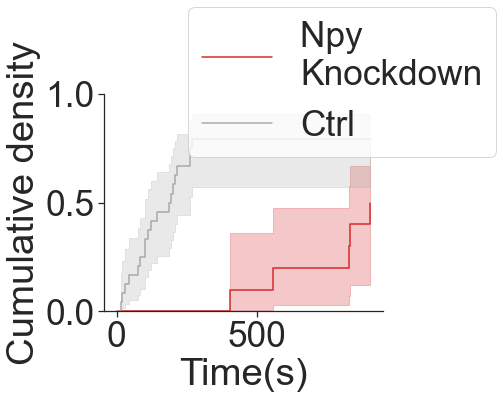

In [36]:
id_invalid = kd_cell_behav[kd_cell_behav.num_detection <100].mice_ID
kd_df = kd_df[~kd_df.mice_ID.isin(id_invalid)]

from lifelines import AalenJohansenFitter

# change palette to orange and gray
sns.set_palette(['Tab:red', 'darkgray'])
plt.rcParams["figure.figsize"] = (5,4)

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(kd_df.aggression_latency,kd_df.aggression_binary , event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(ctrl_df.aggression_latency,ctrl_df.aggression_binary , event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove top and right spines
sns.despine()
plt.ylim([0,1])
plt.xlabel('Time(s)')
plt.ylabel('Cumulative density')

In [37]:
from lifelines.statistics import logrank_test
results = logrank_test(kd_df.aggression_latency, ctrl_df.aggression_latency, event_observed_A=kd_df.aggression_binary, event_observed_B=ctrl_df.aggression_binary)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           6.46 0.01      6.51